In [2]:
# Import pandas for data loading and data handling.
import pandas as pd

# Import numpy for numerical operations.
import numpy as np

# Import pyplot and seaborn express for visualisations.
import matplotlib.pyplot as plt
import seaborn as sns

#Import train test split to split the dataset
from sklearn.model_selection import train_test_split

#Import OneHotEncoder and StandardScaler to encode categorical values and scale numerical values
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [15]:
#Reading csv file and gettinng an insight on the dataset
df = pd.read_csv("loan_approval_data.csv")

#To check the first 10 rows of the dataset as a samole 
df.head()

#To get analytis for each columns on average, mean, count and etc...(.T is used to transpose)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,58645.0,29322.000000,16929.497605,0.00,14661.00,29322.00,43983.00,58644.00
age,58639.0,27.550913,6.033217,20.00,23.00,26.00,30.00,123.00
income,58645.0,64046.172871,37931.106978,4200.00,42000.00,58000.00,75600.00,1900000.00
emplyment_length,58645.0,4.703487,4.004982,0.00,2.00,4.00,7.00,150.00
loan_amount,58645.0,9217.556518,5563.807384,500.00,5000.00,8000.00,12000.00,35000.00
loan_interest_rate,58634.0,10.677526,3.036034,-11.14,7.88,10.75,12.99,23.22
loan_income_ratio,58645.0,0.159238,0.091692,0.00,0.09,0.14,0.21,0.83
credit_history_length,58645.0,5.813556,4.029196,2.00,3.00,4.00,8.00,30.00
loan_approval_status,58645.0,0.142382,0.349445,0.00,0.00,0.00,0.00,1.00
max_allowed_loan,58645.0,69754.717828,61750.913820,-2426900.00,38003.00,62392.00,92716.00,2638778.00


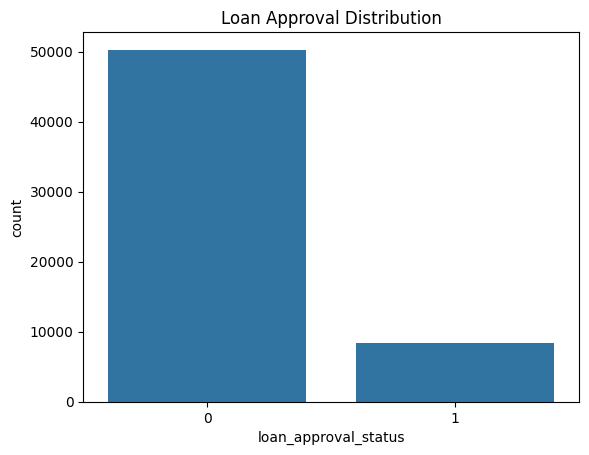

In [16]:
#To check the class distribution between the two values

sns.countplot(x='loan_approval_status', data=df)
plt.title("Loan Approval Distribution")
plt.show()

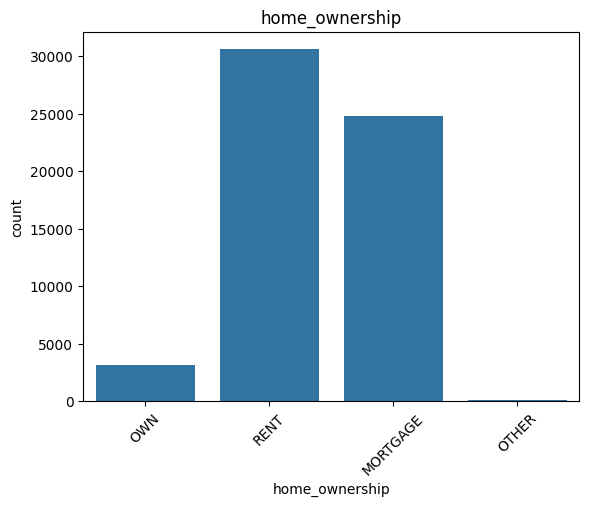

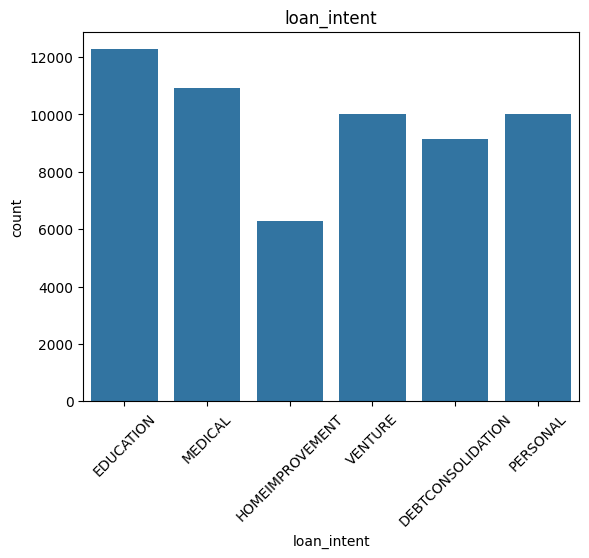

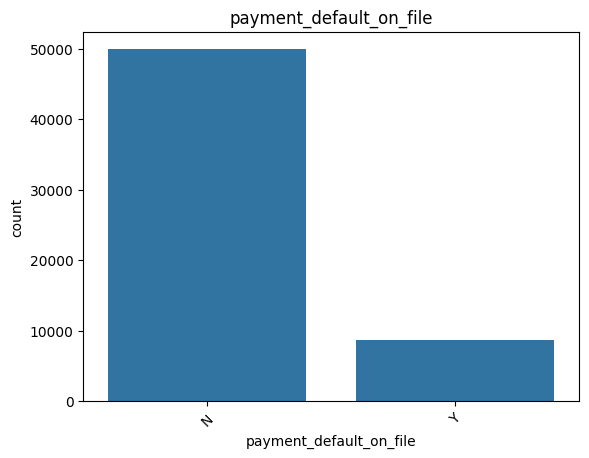

In [17]:
#To see the distribution among categorical values
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    plt.figure()
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.title(col)
    plt.show()

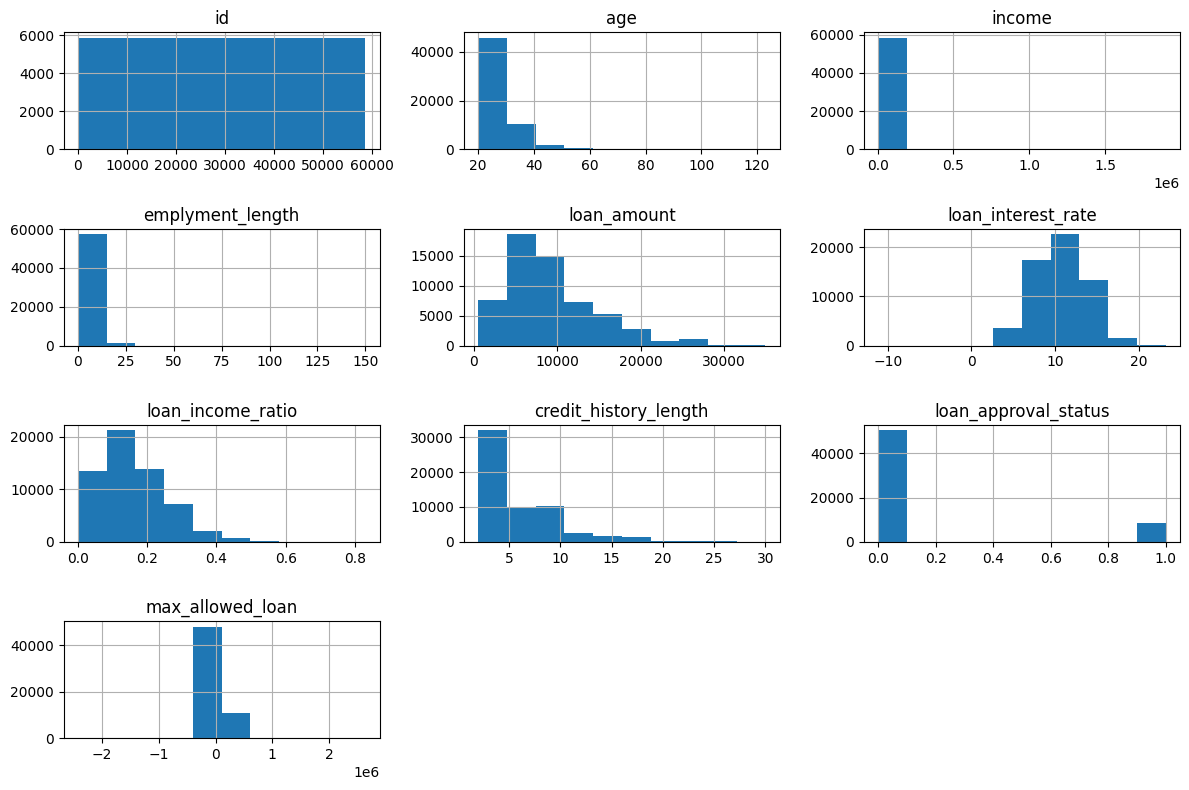

In [18]:
#To see the distribution among numerical values
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[num_cols].hist(figsize=(12,8))
plt.tight_layout()
plt.show()

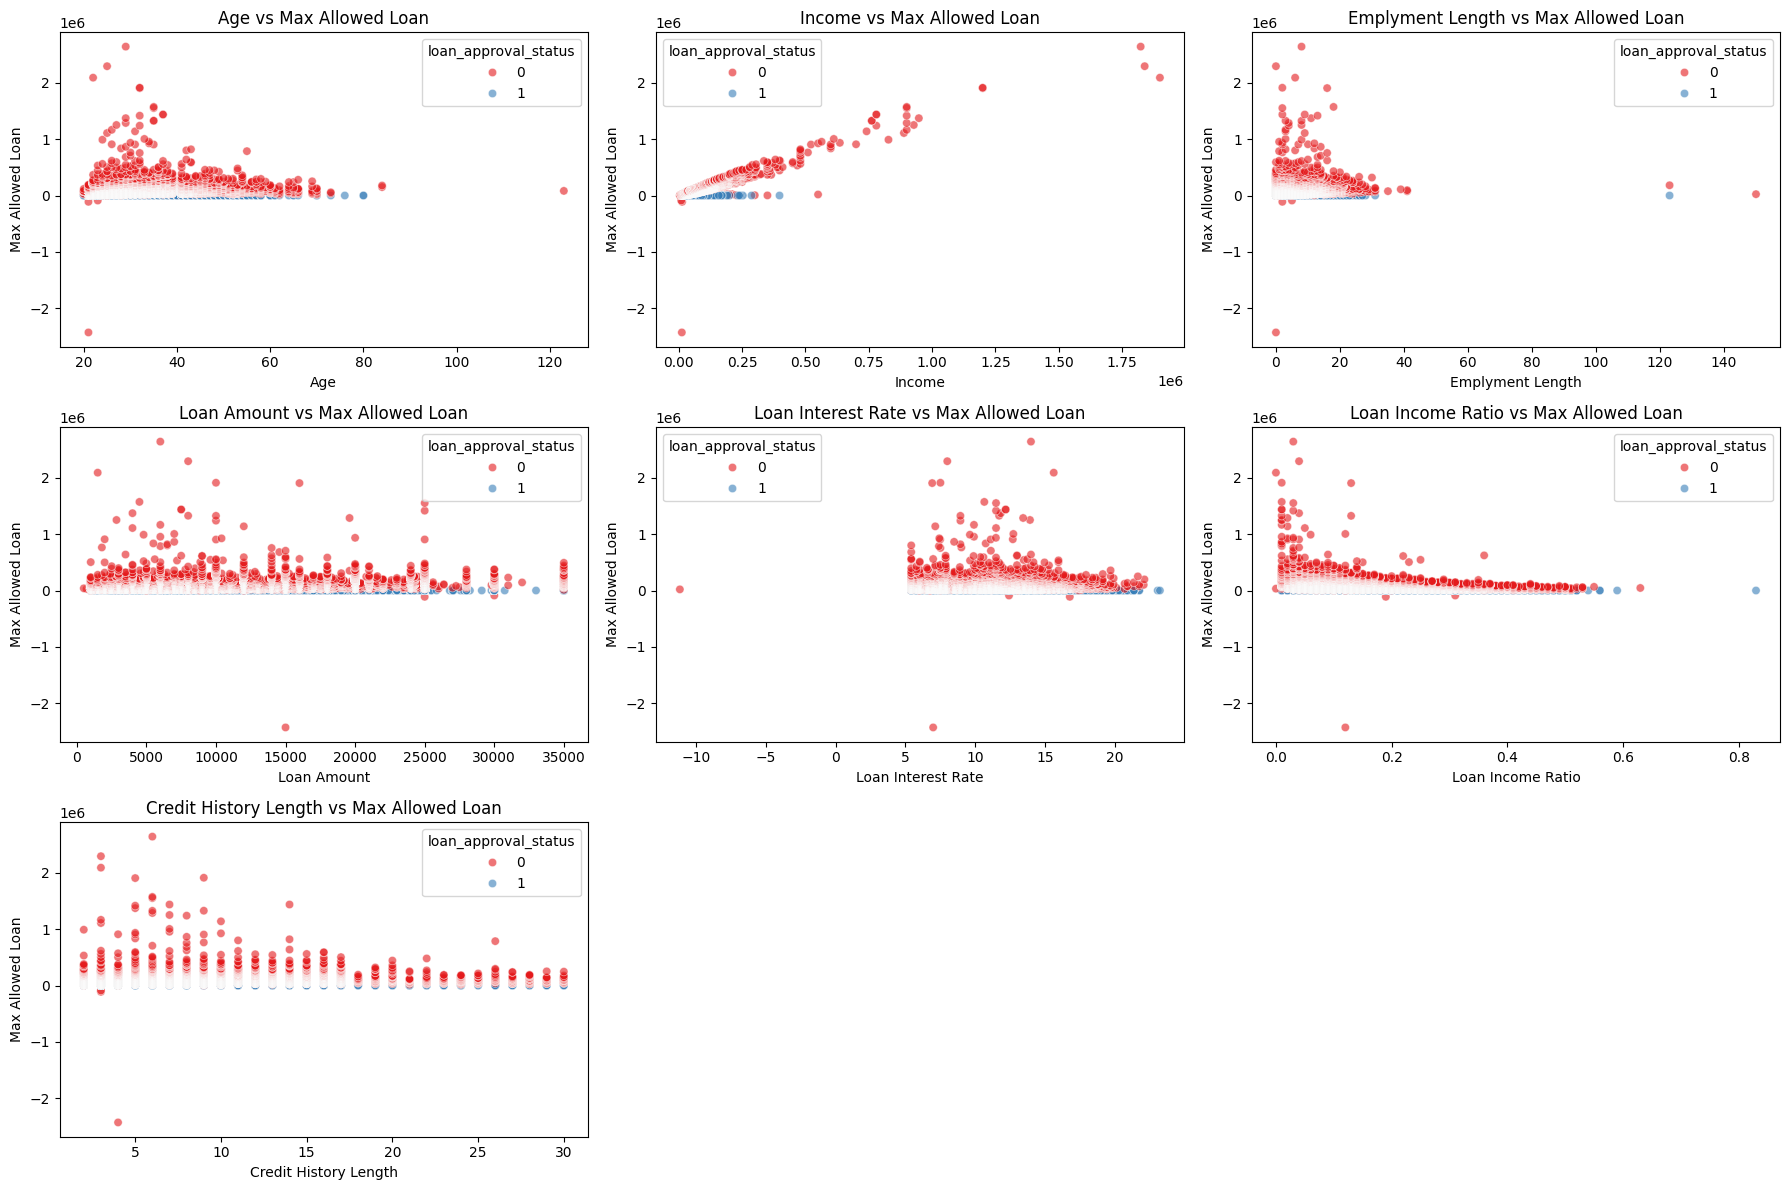

In [23]:
# Define the numerical columns to compare against max_loan_approved and to find outliers'
features_to_plot = [
    'age', 'income', 'emplyment_length', 'loan_amount', 
    'loan_interest_rate', 'loan_income_ratio', 'credit_history_length'
]

# Set up a large figure to hold all the subplots
plt.figure(figsize=(18, 12))

for i, col in enumerate(features_to_plot, 1):
    plt.subplot(3, 3, i)
    
    # Create the scatter plot comparing the feature to max_allowed_loan
    sns.scatterplot(
        x=col, 
        y='max_allowed_loan', 
        hue='loan_approval_status', 
        data=df, 
        alpha=0.6,
        palette='Set1'
    )
    
    # Clean up the labels for a professional report look
    clean_title = col.replace('_', ' ').title()
    plt.title(f'{clean_title} vs Max Allowed Loan')
    plt.xlabel(clean_title)
    plt.ylabel('Max Allowed Loan')

plt.tight_layout()
plt.show()

In [25]:
print(f"Data shape before removing anomalies: {df.shape}")

# Filter the dataset to keep only realistic, valid data points
df_clean = df[
    (df['age'] < 100) & 
    (df['loan_interest_rate'] >= 0) & 
    (df['max_allowed_loan'] >= 0)
]

print(f"Data shape after removing anomalies: {df_clean.shape}")

Data shape before removing anomalies: (58645, 13)
Data shape after removing anomalies: (58623, 13)


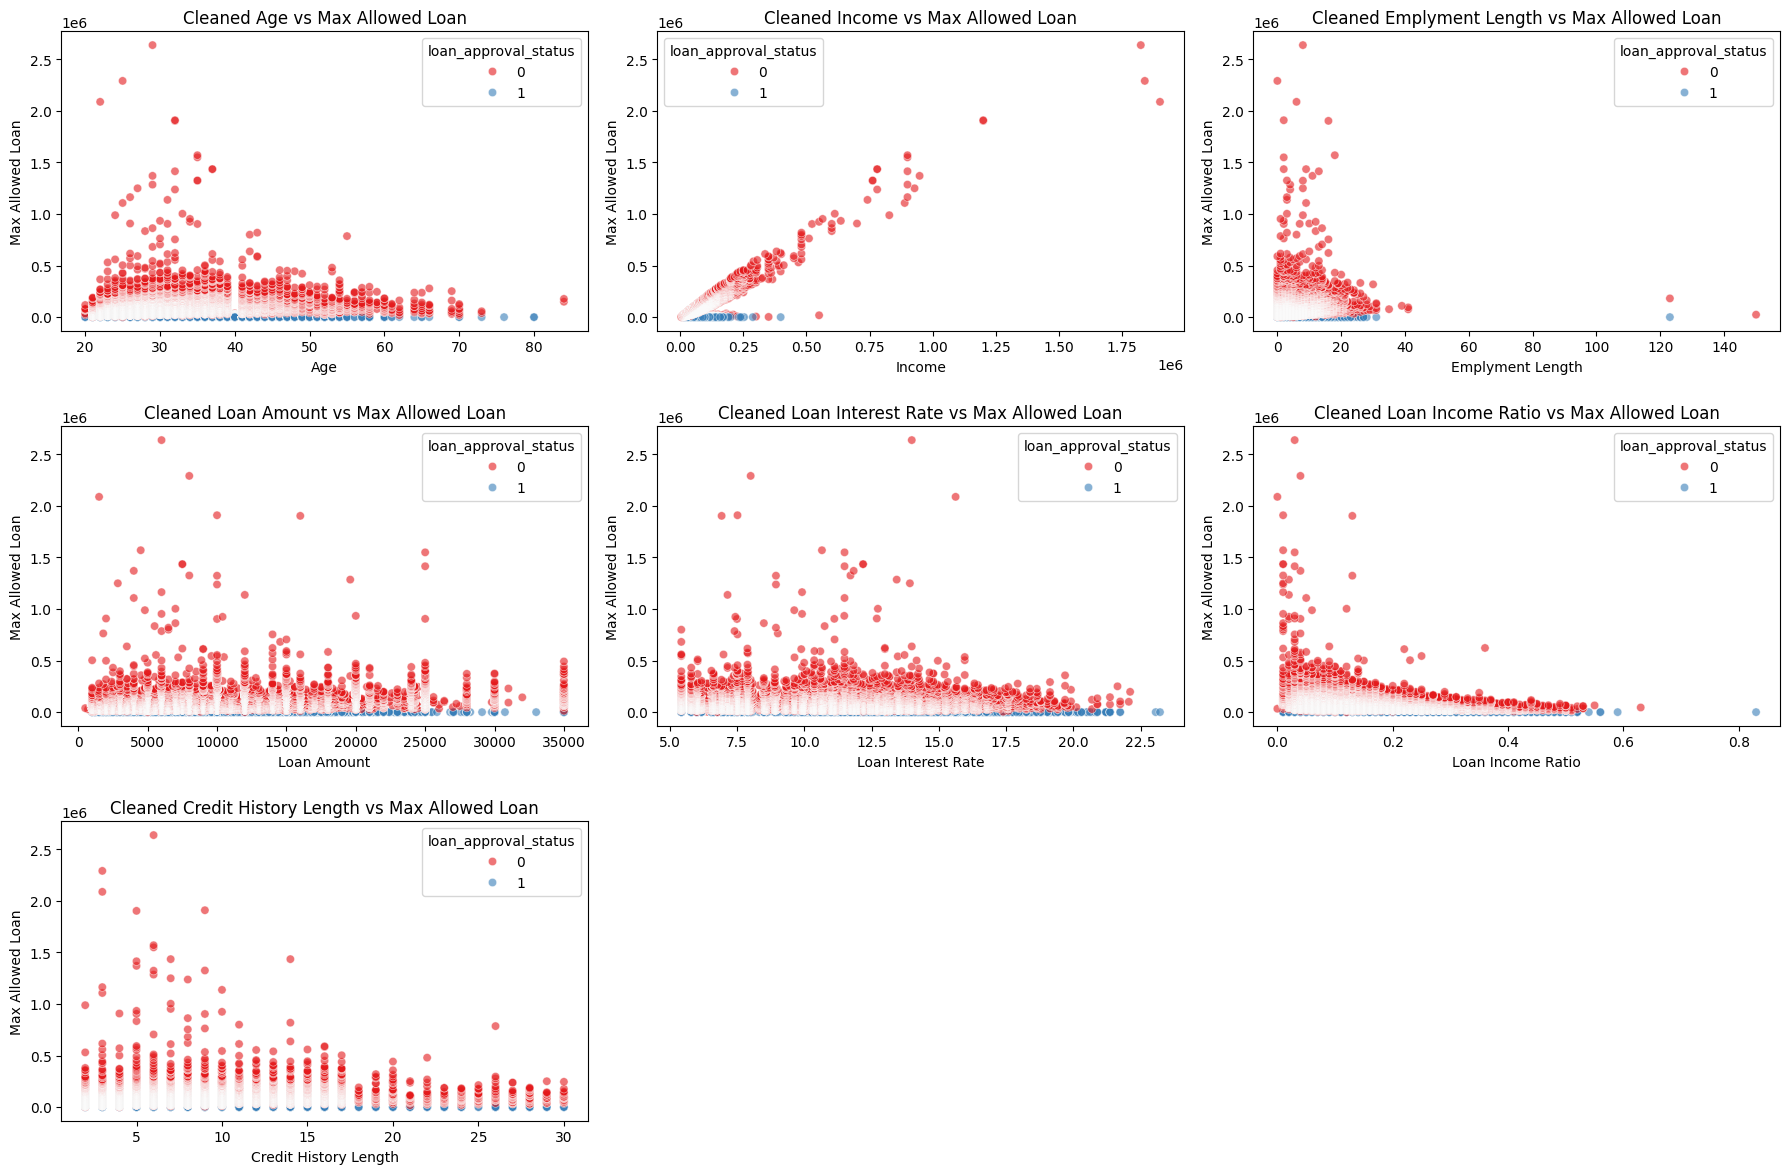

In [28]:
#Visualizing to double check whether the outliers are removed
plt.figure(figsize=(18, 12))

for i, col in enumerate(features_to_plot, 1):
    plt.subplot(3, 3, i)
    sns.scatterplot(
        x=col, 
        y='max_allowed_loan', 
        hue='loan_approval_status', 
        data=df_clean,
        alpha=0.6,
        palette='Set1'
    )
    
    clean_title = col.replace('_', ' ').title()
    plt.title(f'Cleaned {clean_title} vs Max Allowed Loan')
    plt.xlabel(clean_title)
    plt.ylabel('Max Allowed Loan')

plt.tight_layout()
plt.show()

In [30]:
#Check if there are any missing values in the dataset
df_clean.isnull().sum()

id                         0
age                        0
income                     0
home_ownership             0
emplyment_length           0
loan_intent                0
loan_amount                0
loan_interest_rate         0
loan_income_ratio          0
payment_default_on_file    5
credit_history_length      0
loan_approval_status       0
max_allowed_loan           0
dtype: int64

In [33]:
# Calculate the mode (most frequent value)
mode_val = df_clean['payment_default_on_file'].mode()[0]

# Fill the 5 missing spots
df_clean['payment_default_on_file'] = df_clean['payment_default_on_file'].fillna(mode_val)

C:\Users\user\AppData\Local\Temp\ipykernel_19484\4088859816.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['payment_default_on_file'] = df_clean['payment_default_on_file'].fillna(mode_val)


In [34]:
#Double check if there are any missing values in the dataset remaining
df_clean.isnull().sum()

id                         0
age                        0
income                     0
home_ownership             0
emplyment_length           0
loan_intent                0
loan_amount                0
loan_interest_rate         0
loan_income_ratio          0
payment_default_on_file    0
credit_history_length      0
loan_approval_status       0
max_allowed_loan           0
dtype: int64

In [38]:
# Create the classification dataset by dropping ID and maximum allowed loan.
df_class = df_clean.drop(columns=['id','max_allowed_loan'])

# Display the shape of the classification dataset.
print("Classification dataset shape:", df_class.shape)
print()

# Display the column names of the classification dataset.
print("Classification dataset columns:")
print(list(df_class.columns))

# Display the first 10 rows of the classification dataset.
df_class.head(10)

Classification dataset shape: (58623, 11)

Classification dataset columns:
['age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length', 'loan_approval_status']


,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status
3,40.0,182004,RENT,3,EDUCATION,35000,8.00,0.19,N,11,0
4,40.0,90000,MORTGAGE,3,HOMEIMPROVEMENT,35000,12.42,0.39,N,14,0
5,40.0,131004,MORTGAGE,9,VENTURE,30000,7.90,0.23,N,13,0
6,40.0,150000,MORTGAGE,9,DEBTCONSOLIDATION,25000,11.89,0.17,N,11,0
7,40.0,132000,MORTGAGE,3,HOMEIMPROVEMENT,25000,16.82,0.22,N,17,0
8,40.0,80000,MORTGAGE,2,DEBTCONSOLIDATION,25000,10.25,0.31,N,11,0
9,40.0,80000,MORTGAGE,9,VENTURE,25000,18.67,0.30,N,17,0
10,40.0,60000,OWN,5,VENTURE,25000,11.97,0.42,Y,12,0
11,40.0,85000,MORTGAGE,3,HOMEIMPROVEMENT,25000,12.18,0.29,N,16,0
12,40.0,69996,OWN,19,EDUCATION,25000,18.25,0.36,N,14,0


In [39]:
# Create the regression dataset by dropping ID and maximum allowed loan.
df_reg = df_clean[df_clean['loan_approval_status'] == 0]
df_reg = df_reg.drop(columns=['id','loan_approval_status'])

# Display the shape of the classification dataset.
print("Regression dataset shape:", df_reg.shape)
print()

# Display the column names of the classification dataset.
print("Regression dataset columns:")
print(list(df_reg.columns))

# Display the first 10 rows of the classification dataset.
df_reg.head(10)

Regression dataset shape: (50276, 11)

Regression dataset columns:
['age', 'income', 'home_ownership', 'emplyment_length', 'loan_intent', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length', 'max_allowed_loan']


,age,income,home_ownership,emplyment_length,loan_intent,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,max_allowed_loan
3,40.0,182004,RENT,3,EDUCATION,35000,8.00,0.19,N,11,35000
4,40.0,90000,MORTGAGE,3,HOMEIMPROVEMENT,35000,12.42,0.39,N,14,35000
5,40.0,131004,MORTGAGE,9,VENTURE,30000,7.90,0.23,N,13,30000
6,40.0,150000,MORTGAGE,9,DEBTCONSOLIDATION,25000,11.89,0.17,N,11,25000
7,40.0,132000,MORTGAGE,3,HOMEIMPROVEMENT,25000,16.82,0.22,N,17,25000
8,40.0,80000,MORTGAGE,2,DEBTCONSOLIDATION,25000,10.25,0.31,N,11,25000
9,40.0,80000,MORTGAGE,9,VENTURE,25000,18.67,0.30,N,17,25000
10,40.0,60000,OWN,5,VENTURE,25000,11.97,0.42,Y,12,25000
11,40.0,85000,MORTGAGE,3,HOMEIMPROVEMENT,25000,12.18,0.29,N,16,25000
12,40.0,69996,OWN,19,EDUCATION,25000,18.25,0.36,N,14,25000


In [49]:
#Export the dataframes into csv files
df_class.to_csv("classification_dataset.csv", index=False)
df_reg.to_csv("regression_dataset.csv", index=False)